In [1]:
import numpy as np
import pandas as pd
import pingouin as pg
from scipy import stats

import statsmodels.api as sm  # OLS
import seaborn as sns

In [2]:
import os

current_dir = os.getcwd()

def load_data(file_name, drive_id, **kwargs):
    project_path = os.path.join(current_dir, 'data', file_name)
    local_pc_path = os.path.join(r'C:\Users\user\Desktop\Olist Dataset', file_name)
    url = f'https://drive.google.com/uc?export=download&id={drive_id}'
    
    if os.path.exists(project_path):
        return pd.read_csv(project_path, **kwargs)
    elif os.path.exists(local_pc_path):
        return pd.read_csv(local_pc_path, **kwargs)
    else:
        return pd.read_csv(url, **kwargs)

In [3]:
df = load_data('orders_detailed.csv', '1dLU6T8VOwqfDd6dvjQVu7icaY3c_bVMP', encoding='utf-8', sep=',', parse_dates=['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date'],
na_values = ['null', 'unknown', 'unavailable', 'error', 'NaN', 'NULL', 'UNKNOWN', 'ERROR'])

df['delivery_days'] = (df['order_delivered_customer_date'] - df['order_approved_at'])
df['delivery_delay'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date'])
df['delivery_delay'] = df['delivery_delay'].clip(lower=pd.Timedelta(0))

df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state,basket_size,items_total_price,price_per_item,freight_total,payment_installments,total_payment,delivery_days,delivery_delay,review_score
0,0078a358a14592b887eb140ef515f5ab,e1f35a414cbae52d09c294b3e58c3e89,delivered,2017-11-06 15:42:42,2017-11-06 22:36:39,2017-11-08 12:24:40,2017-11-21 19:04:54,2017-11-29,a6f9ff98ef3cedac9d8a2b88afc89972,anapolis,GO,1.0,253.52,253.52,82.86,3.0,336.38,14 days 20:28:15,0 days,5.0
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,eb28e67c4c0b83846050ddfb8a35d051,santa fe do sul,SP,1.0,239.90,239.90,19.93,3.0,259.83,16 days 04:59:11,0 days,4.0
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,3818d81c6709e39d06b2738a8d3a2474,para de minas,MG,1.0,199.00,199.00,17.87,5.0,216.87,7 days 22:30:46,0 days,5.0
3,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,64b576fb70d441e8f1b2d7d446e483c5,varzea paulista,SP,1.0,199.90,199.90,18.14,3.0,218.04,25 days 02:32:18,0 days,5.0
4,00048cc3ae777c65dbb7d2a0634bc1ea,816cbea969fe5b689b39cfc97a506742,delivered,2017-05-15 21:42:34,2017-05-17 03:55:27,2017-05-17 11:05:55,2017-05-22 13:44:35,2017-06-06,85c835d128beae5b4ce8602c491bf385,uberaba,MG,1.0,21.90,21.90,12.69,1.0,34.59,5 days 09:49:08,0 days,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99436,fffa82886406ccf10c7b4e35c4ff2788,a5201e1a6d71a8d21e869151bd5b4085,delivered,2017-12-18 16:33:07,2017-12-18 17:33:04,2017-12-20 18:55:00,2018-01-08 18:23:10,2018-01-24,2a3ab9bf9639491997586882c502540a,tenente ananias,RN,1.0,229.90,229.90,44.02,7.0,273.92,21 days 00:50:06,0 days,4.0
99437,fffb2ef8874127f75b52b643880fd7e0,ca8374c00203cec663bc1eabf0aaede4,delivered,2018-03-30 15:36:49,2018-04-03 05:08:33,2018-04-03 15:12:19,2018-04-16 16:56:38,2018-04-27,6b42acb204802253acec6607ff3a9e0b,cordeiro,RJ,1.0,17.90,17.90,22.06,1.0,39.96,13 days 11:48:05,0 days,5.0
99438,fffc94f6ce00a00581880bf54a75a037,b51593916b4b8e0d6f66f2ae24f2673d,delivered,2018-04-23 13:57:06,2018-04-25 04:11:01,2018-04-25 12:09:00,2018-05-10 22:56:40,2018-05-18,0c9aeda10a71f369396d0c04dce13a64,sao luis,MA,1.0,299.99,299.99,43.41,1.0,343.40,15 days 18:45:39,0 days,5.0
99439,fffcd46ef2263f404302a634eb57f7eb,84c5d4fbaf120aae381fad077416eaa0,delivered,2018-07-14 10:26:46,2018-07-17 04:31:48,2018-07-17 08:05:00,2018-07-23 20:31:55,2018-08-01,0da9fe112eae0c74d3ba1fe16de0988b,curitiba,PR,1.0,350.00,350.00,36.53,1.0,386.53,6 days 16:00:07,0 days,5.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype          
---  ------                         --------------  -----          
 0   order_id                       99441 non-null  object         
 1   customer_id                    99441 non-null  object         
 2   order_status                   98832 non-null  object         
 3   order_purchase_timestamp       99441 non-null  datetime64[ns] 
 4   order_approved_at              99281 non-null  datetime64[ns] 
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns] 
 6   order_delivered_customer_date  96476 non-null  datetime64[ns] 
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns] 
 8   customer_unique_id             99441 non-null  object         
 9   customer_city                  99441 non-null  object         
 10  customer_state                 99441 non-null  object         
 11  ba

In [5]:
df.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,basket_size,items_total_price,price_per_item,freight_total,payment_installments,total_payment,delivery_days,delivery_delay,review_score
count,99441,99281,97658,96476,99441,98666.000000,98666.000000,98666.000000,98666.000000,99440.000000,99440.000000,96462,96476,98673.000000
mean,2017-12-31 08:43:12.776581120,2017-12-31 18:35:24.098800128,2018-01-04 21:49:48.138278656,2018-01-14 12:09:19.035542784,2018-01-24 03:08:37.730111232,1.141731,137.754076,125.919255,22.823562,2.930521,206.955591,12 days 03:07:42.855694470,0 days 18:35:56.612701604,4.086793
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00,1.000000,0.850000,0.850000,0.000000,0.000000,0.000000,-7 days +00:14:54,0 days 00:00:00,1.000000
25%,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.249999872,2017-09-25 22:07:22.249999872,2017-10-03 00:00:00,1.000000,45.900000,41.990000,13.850000,1.000000,62.960000,6 days 07:26:16.250000,0 days 00:00:00,4.000000
50%,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00,1.000000,86.900000,79.000000,17.170000,2.000000,110.240000,9 days 20:27:15.500000,0 days 00:00:00,5.000000
75%,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.249999872,2018-05-25 00:00:00,1.000000,149.900000,139.900000,24.040000,4.000000,196.520000,15 days 03:23:26.750000,0 days 00:00:00,5.000000
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00,21.000000,13440.000000,6735.000000,1794.960000,24.000000,109312.640000,208 days 12:01:24,188 days 23:24:07,5.000000
std,NaN,NaN,NaN,NaN,NaN,0.538452,210.645145,190.985636,21.650909,2.715685,622.552967,9 days 12:24:16.979327481,4 days 18:04:28.108818024,1.346274


In [6]:
df.isnull().sum()

order_id                            0
customer_id                         0
order_status                      609
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
customer_unique_id                  0
customer_city                       0
customer_state                      0
basket_size                       775
items_total_price                 775
price_per_item                    775
freight_total                     775
payment_installments                1
total_payment                       1
delivery_days                    2979
delivery_delay                   2965
review_score                      768
dtype: int64

In [7]:
# PAYMENT INSTALLMENTS AND AVE CHECK

df_inst = df[['payment_installments', 'total_payment']].dropna()

x = df_inst['payment_installments']
y = df_inst['total_payment']
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
print(slope, intercept, r_value, std_err, p_value)

33.84331033814259 107.77706256085608 0.1476304238833962 0.7190113991669704 0.0


In [8]:
x = sm.add_constant(x)
model = sm.OLS(y, x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          total_payment   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     2216.
Date:                Wed, 29 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:58:15   Log-Likelihood:            -7.7978e+05
No. Observations:               99440   AIC:                         1.560e+06
Df Residuals:                   99438   BIC:                         1.560e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  107.7771 

In [9]:
# BREUSCH-PAGAN TEST  (HETEROSKEDASTICITY)
from statsmodels.stats.diagnostic import het_breuschpagan

labels = ['LM Stat', 'LM p-value', 'F-Stat', 'F p-value']
test_results = het_breuschpagan(model.resid, sm.add_constant(x))

print(dict(zip(labels, test_results)))

{'LM Stat': np.float64(0.048780356789537294), 'LM p-value': np.float64(0.8251992980412766), 'F-Stat': np.float64(0.048779399616039686), 'F p-value': np.float64(0.8252014387796329)}


In [10]:
df_inst['installments_sq'] = df_inst['payment_installments'] ** 2

X = sm.add_constant(df_inst[['payment_installments', 'installments_sq']])
model = sm.OLS(df_inst['total_payment'], X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          total_payment   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     1193.
Date:                Wed, 29 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:58:16   Log-Likelihood:            -7.7970e+05
No. Observations:               99440   AIC:                         1.559e+06
Df Residuals:                   99437   BIC:                         1.559e+06
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  143.2341 

In [11]:
# CUTTING OUTLIERS

df_inst_filt = df_inst[(df_inst['payment_installments'] <= 9) & (df_inst['payment_installments'] > 0) & (df_inst['total_payment'] <= 2000) & (df_inst['total_payment'] > 0)]

x = df_inst_filt['payment_installments']
y = df_inst_filt['total_payment']

x = sm.add_constant(x)
model = sm.OLS(y, x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          total_payment   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     5019.
Date:                Wed, 29 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:58:16   Log-Likelihood:            -6.2371e+05
No. Observations:               93305   AIC:                         1.247e+06
Df Residuals:                   93303   BIC:                         1.247e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  109.6279 

In [12]:
X = sm.add_constant(df_inst_filt[['payment_installments', 'installments_sq']])
model = sm.OLS(df_inst_filt['total_payment'], X).fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          total_payment   R-squared:                       0.052
Model:                            OLS   Adj. R-squared:                  0.052
Method:                 Least Squares   F-statistic:                     1539.
Date:                Wed, 29 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:58:16   Log-Likelihood:            -6.2364e+05
No. Observations:               93305   AIC:                         1.247e+06
Df Residuals:                   93302   BIC:                         1.247e+06
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  124.7367 

In [13]:
# BREUSCH-PAGAN TEST  (HETEROSKEDASTICITY)
from statsmodels.stats.diagnostic import het_breuschpagan

labels = ['LM Stat', 'LM p-value', 'F-Stat', 'F p-value']
test_results = het_breuschpagan(model.resid, sm.add_constant(x))

print(dict(zip(labels, test_results)))

{'LM Stat': np.float64(492.4878381260243), 'LM p-value': np.float64(4.097223446967083e-109), 'F-Stat': np.float64(495.09049685596773), 'F p-value': np.float64(2.1456769772982594e-109)}


In [14]:
# RAMSEY TEST

import statsmodels.stats.diagnostic as dg

reset_results = dg.linear_reset(model, power=3, use_f=True)
reset_results

<class 'statsmodels.stats.contrast.ContrastResults'>
<F test: F=43.04817118021393, p=2.0560683580690583e-19, df_denom=9.33e+04, df_num=2>

In [15]:
# RAMSEY TEST  (X-squared ADDED)

import statsmodels.stats.diagnostic as dg

reset_results = dg.linear_reset(model, power=3, use_f=True)
reset_results

<class 'statsmodels.stats.contrast.ContrastResults'>
<F test: F=43.04817118021393, p=2.0560683580690583e-19, df_denom=9.33e+04, df_num=2>

In [16]:
# OLS WITH LOGARITHM

df_inst_filt['log_payment'] = np.log(df_inst_filt['total_payment']).copy()

model = sm.OLS(df_inst_filt['log_payment'], X).fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            log_payment   R-squared:                       0.095
Model:                            OLS   Adj. R-squared:                  0.095
Method:                 Least Squares   F-statistic:                     5064.
Date:                Wed, 29 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:58:16   Log-Likelihood:            -1.1111e+05
No. Observations:               93305   AIC:                         2.222e+05
Df Residuals:                   93302   BIC:                         2.223e+05
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    4.3683 

C:\Users\user\AppData\Local\Temp\ipykernel_28120\1308867176.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_inst_filt['log_payment'] = np.log(df_inst_filt['total_payment']).copy()


In [17]:
# BREUSCH-PAGAN TEST  (WITH LOGS)

labels = ['LM Stat', 'LM p-value', 'F-Stat', 'F p-value']
test_results = het_breuschpagan(model.resid, sm.add_constant(x))

print(dict(zip(labels, test_results)))

{'LM Stat': np.float64(71.84200354010852), 'LM p-value': np.float64(2.331363818533147e-17), 'F-Stat': np.float64(71.89582119010667), 'F p-value': np.float64(2.3011422257196197e-17)}


In [18]:
# TEST D'AGOSTINO

from scipy.stats import normaltest

for name, group in df_inst.groupby('payment_installments'):
    k2, p = stats.normaltest(group['total_payment'])
    if p < 0.05:
        print(f"Group {name}: The distribution is NOT normal (p={p:.2f})")
    else:
        print(f"Group {name}: The distribution is normal (p={p:.2f})")

Group 0.0: The distribution is normal (p=nan)
Group 1.0: The distribution is NOT normal (p=0.00)
Group 2.0: The distribution is NOT normal (p=0.00)
Group 3.0: The distribution is NOT normal (p=0.00)
Group 4.0: The distribution is NOT normal (p=0.00)
Group 5.0: The distribution is NOT normal (p=0.00)
Group 6.0: The distribution is NOT normal (p=0.00)
Group 7.0: The distribution is NOT normal (p=0.00)
Group 8.0: The distribution is NOT normal (p=0.00)
Group 9.0: The distribution is NOT normal (p=0.00)
Group 10.0: The distribution is NOT normal (p=0.00)
Group 11.0: The distribution is NOT normal (p=0.00)
Group 12.0: The distribution is NOT normal (p=0.00)
Group 13.0: The distribution is normal (p=0.14)
Group 14.0: The distribution is NOT normal (p=0.00)
Group 15.0: The distribution is NOT normal (p=0.00)
Group 16.0: The distribution is normal (p=nan)
Group 17.0: The distribution is normal (p=0.76)
Group 18.0: The distribution is NOT normal (p=0.00)
Group 20.0: The distribution is NOT norm

C:\Users\user\AppData\Local\Temp\ipykernel_28120\992781325.py:6: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  k2, p = stats.normaltest(group['total_payment'])


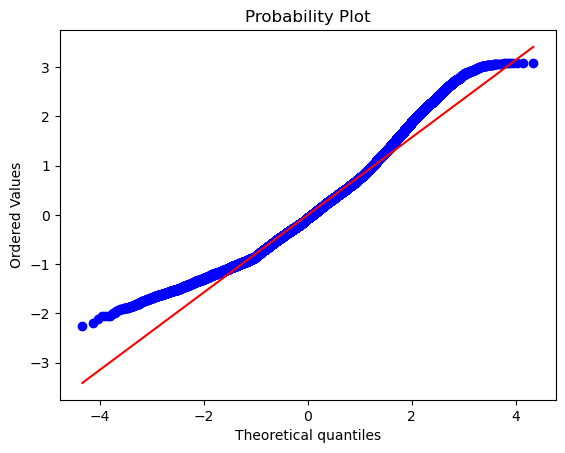

In [19]:
import matplotlib.pyplot as plt

stats.probplot(model.resid, dist='norm', plot=plt)
plt.show()

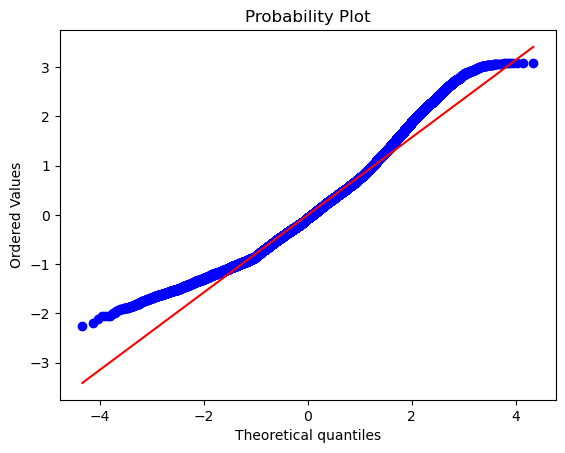

In [20]:
# QQ PLOT FOR MODEL WITH LOGS

stats.probplot(model.resid, dist='norm', plot=plt)
plt.show()

In [21]:
from scipy.stats import kruskal

groups = [group['total_payment'].values for name, group in df_inst.groupby('payment_installments')]
stat, p = kruskal(*groups)
stat, p

(np.float64(15968.909055832873), np.float64(0.0))

In [22]:
import scikit_posthocs as sp

dunn = sp.posthoc_dunn(
    df_inst,
    val_col = 'total_payment',
    group_col = 'payment_installments',
    p_adjust = 'bonferroni'
)

dunn

,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,14.0,15.0,16.0,17.0,18.0,20.0,21.0,22.0,23.0,24.0
0.0,1.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,1.000000,1.000000e+00,1.0,1.0,1.000000e+00,1.000000e+00,1.0,1.0,1.0,1.000000e+00
1.0,1.0,1.000000e+00,1.505646e-160,1.046343e-234,2.525334e-293,0.000000e+00,0.000000e+00,4.747943e-138,0.000000e+00,1.979477e-78,...,0.054473,1.360154e-37,1.0,1.0,3.816703e-15,1.302087e-10,1.0,1.0,1.0,2.742354e-12
2.0,1.0,1.505646e-160,1.000000e+00,3.298810e-07,3.410055e-36,9.931798e-84,2.601756e-140,1.706249e-40,0.000000e+00,3.021501e-30,...,1.000000,4.827295e-25,1.0,1.0,3.292081e-10,2.935498e-07,1.0,1.0,1.0,1.358802e-08
3.0,1.0,1.046343e-234,3.298810e-07,1.000000e+00,6.179973e-11,1.834147e-44,1.151285e-91,1.240114e-23,0.000000e+00,1.694682e-20,...,1.000000,8.007292e-22,1.0,1.0,6.364502e-09,2.244298e-06,1.0,1.0,1.0,1.290351e-07
4.0,1.0,2.525334e-293,3.410055e-36,6.179973e-11,1.000000e+00,2.093222e-10,2.956841e-40,2.342462e-07,2.723854e-289,7.987606e-10,...,1.000000,1.199112e-17,1.0,1.0,3.017229e-07,3.227528e-05,1.0,1.0,1.0,2.487006e-06
5.0,1.0,0.000000e+00,9.931798e-84,1.834147e-44,2.093222e-10,1.000000e+00,4.804445e-09,1.000000e+00,9.968408e-170,4.859808e-02,...,1.000000,2.371743e-13,1.0,1.0,1.707107e-05,5.404505e-04,1.0,1.0,1.0,5.743269e-05
6.0,1.0,0.000000e+00,2.601756e-140,1.151285e-91,2.956841e-40,4.804445e-09,1.000000e+00,1.173212e-01,1.611531e-83,1.000000e+00,...,1.000000,2.612960e-09,1.0,1.0,8.228169e-04,8.410937e-03,1.0,1.0,1.0,1.241863e-03
7.0,1.0,4.747943e-138,1.706249e-40,1.240114e-23,2.342462e-07,1.000000e+00,1.173212e-01,1.000000e+00,7.236388e-74,1.000000e+00,...,1.000000,8.017220e-12,1.0,1.0,5.927335e-05,1.258093e-03,1.0,1.0,1.0,1.492225e-04
8.0,1.0,0.000000e+00,0.000000e+00,0.000000e+00,2.723854e-289,9.968408e-170,1.611531e-83,7.236388e-74,1.000000e+00,6.468461e-21,...,1.000000,5.238948e-01,1.0,1.0,1.000000e+00,1.000000e+00,1.0,1.0,1.0,1.000000e+00
9.0,1.0,1.979477e-78,3.021501e-30,1.694682e-20,7.987606e-10,4.859808e-02,1.000000e+00,1.000000e+00,6.468461e-21,1.000000e+00,...,1.000000,4.371676e-08,1.0,1.0,1.710342e-03,1.318865e-02,1.0,1.0,1.0,2.117161e-03


<Axes: xlabel='payment_installments', ylabel='total_payment'>

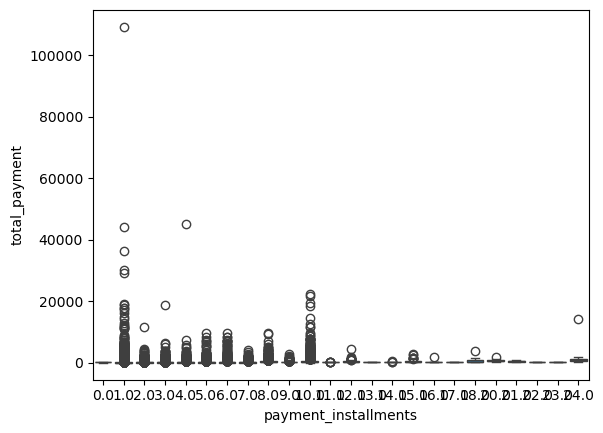

In [23]:
sns.boxplot(y='total_payment', x='payment_installments', data=df_inst)

<Axes: xlabel='payment_installments', ylabel='total_payment'>

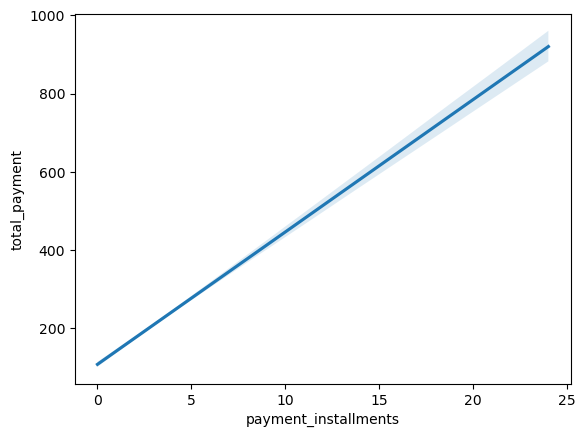

In [24]:
sns.regplot(x='payment_installments', y='total_payment', data=df_inst, scatter=False)

In [25]:
#pg.welch_anova(dv='ave_check', between='installments', data=df_inst)

group_a = df[df['payment_installments'] == 1]['total_payment']
group_b = df[df['payment_installments'] == 2]['total_payment']
group_c = df[df['payment_installments'] == 3]['total_payment']

t_stat1, p_value1 = stats.ttest_ind(group_a, group_b)
t_stat2, p_value2 = stats.ttest_ind(group_a, group_c)
t_stat3, p_value3 = stats.ttest_ind(group_b, group_c)

print(t_stat1, p_value1)
print(t_stat2, p_value2)
print(t_stat3, p_value3)

1.4491943949105297 0.14728847447670612
-2.177317971148169 0.029460820781077167
-7.284903190648953 3.3236904978745566e-13


In [26]:
# BASKET SIZE & PRICE PER ITEM

df_bs = df[['basket_size', 'price_per_item']].dropna()
df_bs = df_bs[df_bs['basket_size'] <= 6]
x, y = df_bs['basket_size'], df_bs['price_per_item']
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
slope, intercept, r_value, p_value, std_err

(np.float64(-24.409541050105926),
 np.float64(153.67874749106215),
 np.float64(-0.06269019479343582),
 np.float64(1.9514066878221563e-86),
 np.float64(1.2375228895287143))

In [27]:
x = sm.add_constant(x)
model = sm.OLS(y, x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         price_per_item   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     389.1
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           1.95e-86
Time:                        11:58:51   Log-Likelihood:            -6.5762e+05
No. Observations:               98608   AIC:                         1.315e+06
Df Residuals:                   98606   BIC:                         1.315e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         153.6787      1.532    100.308      

In [28]:
df_bs['basket_sq'] = df_bs['basket_size'] ** 2
x = df_bs[['basket_size', 'basket_sq']]

x = sm.add_constant(x)
model = sm.OLS(y, x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         price_per_item   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     239.4
Date:                Wed, 29 Apr 2026   Prob (F-statistic):          1.83e-104
Time:                        11:58:51   Log-Likelihood:            -6.5758e+05
No. Observations:               98608   AIC:                         1.315e+06
Df Residuals:                   98605   BIC:                         1.315e+06
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         183.6715      3.521     52.163      

In [29]:
# RAMSEY TEST

reset_results = dg.linear_reset(model, power=3, use_f=True)
reset_results

<class 'statsmodels.stats.contrast.ContrastResults'>
<F test: F=7.676814665214701, p=0.000463725839773003, df_denom=9.86e+04, df_num=2>

In [30]:
# RAMSEY TEST HAVING BASKET_SQ

reset_results = dg.linear_reset(model, power=3, use_f=True)
reset_results

<class 'statsmodels.stats.contrast.ContrastResults'>
<F test: F=7.676814665214701, p=0.000463725839773003, df_denom=9.86e+04, df_num=2>

In [31]:
# BREUSCH-PAGAN TEST

labels = ['LM Stat', 'LM p-value', 'F-Stat', 'F p-value']
test_results = het_breuschpagan(model.resid, model.model.exog)

print(dict(zip(labels, test_results)))

{'LM Stat': np.float64(44.408656633033175), 'LM p-value': np.float64(2.273959564308735e-10), 'F-Stat': np.float64(22.21365682610781), 'F p-value': np.float64(2.2641442579103185e-10)}


In [32]:
# LOGARITHM ADDED

df_bs['log_item_price'] = np.log(df_bs['price_per_item'])

x = df_bs[['basket_size', 'basket_sq']]

x = sm.add_constant(x)
model = sm.OLS(df_bs['log_item_price'], x).fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         log_item_price   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     585.6
Date:                Wed, 29 Apr 2026   Prob (F-statistic):          1.45e-253
Time:                        11:58:51   Log-Likelihood:            -1.3138e+05
No. Observations:               98608   AIC:                         2.628e+05
Df Residuals:                   98605   BIC:                         2.628e+05
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           4.7067      0.016    294.359      

In [33]:
pg.welch_anova(dv='price_per_item', between='basket_size', data=df_bs)

,Source,ddof1,ddof2,F,p-unc,np2
0,basket_size,5,931.219724,280.061547,9.167922e-183,0.00499


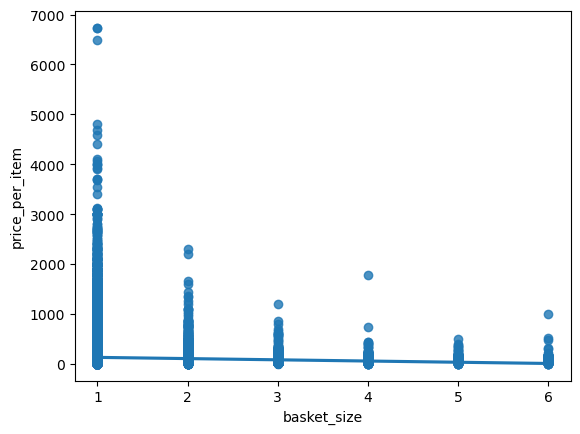

In [34]:
sns.regplot(x='basket_size', y='price_per_item', data=df_bs)
plt.show()

In [35]:
df[df['order_delivered_customer_date'] < df['order_delivered_carrier_date']]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state,basket_size,items_total_price,price_per_item,freight_total,payment_installments,total_payment,delivery_days,delivery_delay,review_score
1822,0922ee1619de7b995648e5a8407afb91,8dab637615e9eae6d33ef5e48644d6d3,delivered,2017-07-11 10:45:44,2017-07-11 10:55:15,2017-07-14 12:41:34,2017-07-12 20:49:42,2017-08-14,4f390e1c2c37c847e3c6aaa76121aa0d,sao paulo,SP,2.0,204.80,102.400000,44.29,5.0,498.18,1 days 09:54:27,0 days,1.0
5530,1cc3ae63caffff2d6c3ee3e78e074acf,01c843a2c0600def0b7693dba47af460,delivered,2017-08-07 21:35:22,2017-08-08 21:45:15,2017-08-10 18:28:56,2017-08-10 18:05:38,2017-08-25,f3d176999f9c1273045f770712608944,mogi das cruzes,SP,2.0,127.89,63.945000,23.57,6.0,302.92,1 days 20:20:23,0 days,2.0
7988,29941903985f944b0ffc49c479c1547d,b56ee98181afc3948a758d73a08423de,delivered,2017-05-29 16:16:50,2017-05-29 16:25:16,2017-06-09 15:07:29,2017-06-02 11:09:16,2017-06-23,bf0a805b588b889511e15496905cf7c5,bento de abreu,SP,2.0,289.98,144.990000,30.81,4.0,641.58,3 days 18:44:00,0 days,5.0
18431,5f9d46795c3126674e52becb3a1a517f,79287bcaafdde5c793b996fc40bb7d9f,delivered,2017-07-18 11:48:20,2017-07-18 12:03:29,2017-07-20 23:03:42,2017-07-20 18:52:41,2017-07-31,9ba29e899022cb28eb0f845eeb5f0116,mogi das cruzes,SP,2.0,178.90,89.450000,44.79,8.0,447.38,2 days 06:49:12,0 days,1.0
22887,76458889992169d3135b264dc13aec67,999196dca58a3db3d966d8f148532010,delivered,2016-10-07 10:05:16,2016-10-07 11:24:43,2016-10-26 11:43:06,2016-10-20 18:03:17,2016-11-29,a6a1951929248912bcccea06be552ea2,santos,SP,1.0,73.35,73.350000,12.23,2.0,85.58,13 days 06:38:34,0 days,5.0
27133,8c78d01de3a9009e23d6877a7cc9be20,6cd7106899e59a1fbd0622d5f1efedf4,delivered,2016-10-08 15:36:50,2016-10-08 18:13:44,2016-10-26 11:41:53,2016-10-25 17:51:46,2016-11-30,6360ff9a3d58800ba0b03b1c6c290d92,mongagua,SP,2.0,219.80,109.900000,29.92,7.0,499.44,16 days 23:38:02,0 days,3.0
34603,b27af682321527a6349f1761eb3f360c,9859dd92e872dbaa60ca3cd5f0d7ad07,delivered,2017-06-14 20:17:04,2017-06-14 20:30:08,2017-06-27 14:51:54,2017-06-26 15:45:35,2017-07-14,0ec0111adb427dd69d1803a42c15eca6,guarulhos,SP,2.0,141.89,70.945000,37.24,10.0,358.26,11 days 19:15:27,0 days,1.0
39386,cb1134f9010d242e9515ad1c78ec0c39,2fd33ac77677bd214b1882868317eeed,delivered,2017-07-16 12:35:34,2017-07-18 06:03:50,2017-07-20 19:22:02,2017-07-19 14:13:28,2017-08-08,8518c7888966eddd34b73abcc5165b07,sao bernardo do campo,SP,2.0,124.80,62.400000,15.26,1.0,280.12,1 days 08:09:38,0 days,3.0
41537,d5558a097766363b8e76b38c43332e8a,49a4fe701c3d30eac6c180908e665ebb,delivered,2017-02-04 19:01:33,2017-02-04 19:31:12,2017-02-15 08:55:26,2017-02-10 07:58:32,2017-03-01,8612673f1121d1da48f141ee9dceb20b,sao paulo,SP,2.0,108.60,54.300000,20.51,3.0,258.22,5 days 12:27:20,0 days,2.0
45481,ea1dcb4757a844d2642547797bd5feb0,4999e129610251dec1e6fb712dc15171,delivered,2017-07-18 13:38:29,2017-07-18 13:50:23,2017-07-27 19:21:31,2017-07-25 19:43:10,2017-08-15,a6cc2b0e951069e78ca04b7c5d68d8af,porto alegre,RS,2.0,157.00,78.500000,30.59,9.0,375.18,7 days 05:52:47,0 days,1.0


In [36]:
pg.welch_anova(dv='review_score', between='delivery_delay', data=df)

C:\Users\user\anaconda3\Lib\site-packages\pingouin\parametric.py:1346: RuntimeWarning: invalid value encountered in scalar divide
  adj_grandmean = (weights * grp.mean(numeric_only=True)).sum() / weights.sum()


,Source,ddof1,ddof2,F,p-unc,np2
0,delivery_delay,7754,431111.177999,0.0,1.0,0.267966


In [37]:
# REGRESSION: REVIEW SCORE ON DELAY DAYS

import statsmodels.api as sm

df['delay_days'] = df['delivery_delay'].dt.total_seconds() / 86400
df_nona = df.dropna(subset=['delay_days', 'review_score'])

x = sm.add_constant(df_nona['delay_days'])
y = df_nona['review_score']

model = sm.OLS(y, x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           review_score   R-squared:                       0.074
Model:                            OLS   Adj. R-squared:                  0.074
Method:                 Least Squares   F-statistic:                     7678.
Date:                Wed, 29 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:59:29   Log-Likelihood:            -1.5622e+05
No. Observations:               95830   AIC:                         3.124e+05
Df Residuals:                   95828   BIC:                         3.125e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.2127      0.004   1042.168      0.0

In [38]:
# SPEARMAN CORRELATION

from scipy.stats import spearmanr

df_clean = df[['delay_days', 'review_score', 'items_total_price', 'freight_total']].dropna()
df_clean['delay_sq'] = df_clean['delay_days'] ** 2

spearmanr(df_clean['delay_days'], df_clean['review_score'])

SignificanceResult(statistic=np.float64(-0.30004972638100436), pvalue=np.float64(0.0))

In [39]:
slope, intercept, r_value, p_value, std_err = stats.linregress(df_clean['delay_days'], df_clean['review_score'])
print(slope, intercept, r_value, std_err, p_value)

-0.07501229530711843 4.212677867930999 -0.2723651018343385 0.0008560466192321063 0.0


<Axes: xlabel='delay_days', ylabel='review_score'>

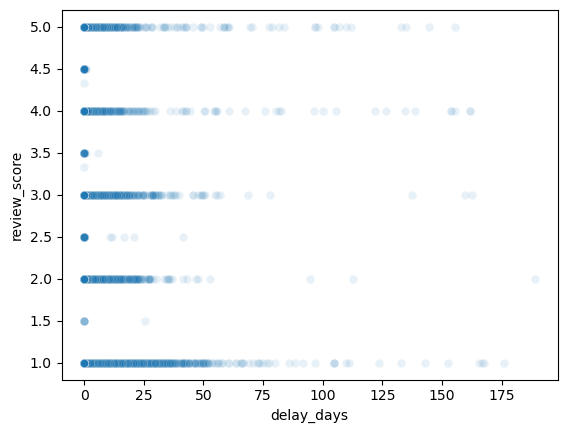

In [40]:
sns.scatterplot(x='delay_days', y='review_score', data=df_clean, alpha=0.1)

<Axes: xlabel='delay_days', ylabel='review_score'>

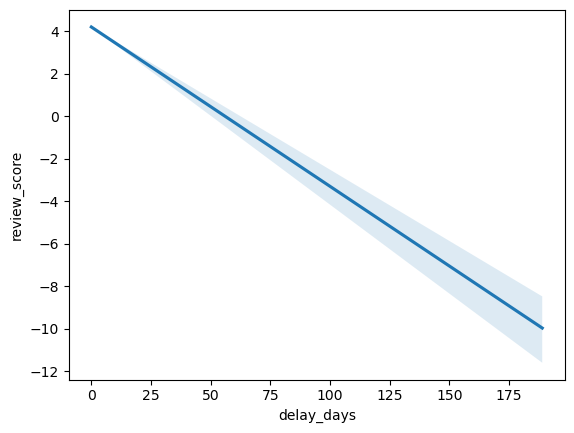

In [41]:
sns.regplot(x='delay_days', y='review_score', data=df_clean, scatter=False)

                            OLS Regression Results                            
Dep. Variable:           review_score   R-squared:                       0.120
Model:                            OLS   Adj. R-squared:                  0.120
Method:                 Least Squares   F-statistic:                 1.302e+04
Date:                Wed, 29 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:00:29   Log-Likelihood:            -1.5360e+05
No. Observations:               95750   AIC:                         3.072e+05
Df Residuals:                   95748   BIC:                         3.072e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.2437      0.004   1070.859      0.0

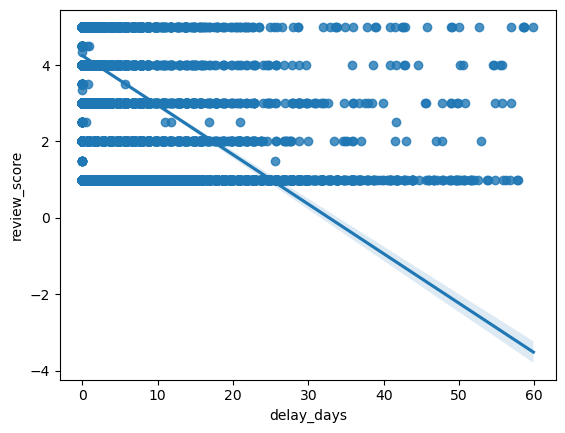

In [42]:
# DATA CONTROL (DELAY DAYS <= 60)

df_clean_f = df_clean[df_clean['delay_days'] <= 60]
sns.regplot(x='delay_days', y='review_score', data=df_clean_f)

x = sm.add_constant(df_clean_f['delay_days'])
y = df_clean_f['review_score']

model = sm.OLS(y, x).fit()
print(model.summary())

In [43]:
slope, intercept, r_value, p_value, std_err = stats.linregress(df_clean_f['delay_days'], df_clean_f['review_score'])
print(slope, intercept, r_value, std_err, p_value)

-0.12949478696006342 4.24371932882593 -0.34594363657053423 0.0011350189381687992 0.0


In [44]:
# RAMSEY TEST

X = sm.add_constant(df_clean_f[['delay_days']])
model = sm.OLS(df_clean_f['review_score'], X).fit()

import statsmodels.stats.diagnostic as dg

reset_results = dg.linear_reset(model, power=3, use_f=True)

reset_results

<class 'statsmodels.stats.contrast.ContrastResults'>
<F test: F=3034.5583434789405, p=0.0, df_denom=9.57e+04, df_num=2>

In [45]:
# NON-LINEAR RELATIONSHIP

#df_clean['delay_sq'] = df_clean['delay_days'] ** 2

X = sm.add_constant(df_clean[['delay_days', 'delay_sq']])
model = sm.OLS(df_clean['review_score'], X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           review_score   R-squared:                       0.128
Model:                            OLS   Adj. R-squared:                  0.128
Method:                 Least Squares   F-statistic:                     7055.
Date:                Wed, 29 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:00:31   Log-Likelihood:            -1.5333e+05
No. Observations:               95830   AIC:                         3.067e+05
Df Residuals:                   95827   BIC:                         3.067e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.2508      0.004   1075.282      0.0

In [46]:
# NON-LINEAR RELATIONSHIP & CONTROL (DELAY DAYS <= 60)

X = sm.add_constant(df_clean_f[['delay_days', 'delay_sq']])
model = sm.OLS(df_clean_f['review_score'], X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           review_score   R-squared:                       0.163
Model:                            OLS   Adj. R-squared:                  0.163
Method:                 Least Squares   F-statistic:                     9290.
Date:                Wed, 29 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:00:31   Log-Likelihood:            -1.5121e+05
No. Observations:               95750   AIC:                         3.024e+05
Df Residuals:                   95747   BIC:                         3.025e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.2780      0.004   1098.003      0.0

In [47]:
# HUBER REGRESSION (ROBUST)

from sklearn.linear_model import HuberRegressor

huber = HuberRegressor(epsilon=1.35) #alpha=0.0, fit_intercept=True)
huber.fit(X, df_clean_f['review_score'])
huber.intercept_, huber.coef_

(np.float64(2.3018996698573875),
 array([ 2.30189966, -0.34602686,  0.00725342]))

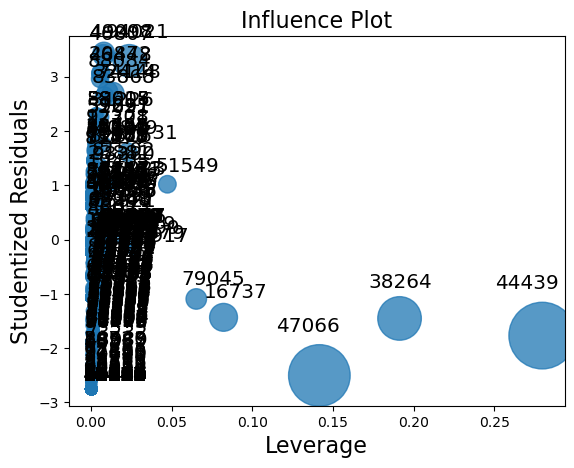

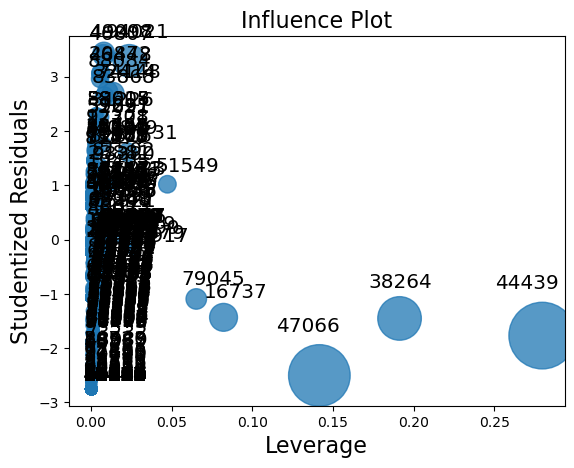

In [48]:
#sm.graphics.influence_plot(model, criterion='cooks')

sample = df_clean_f.sample(5000, random_state=42)
model_sample = sm.OLS(sample['review_score'], sm.add_constant(sample[['delay_days', 'delay_sq']])).fit()
sm.graphics.influence_plot(model_sample, criterion='cooks')

In [49]:
df_clean_f.loc[[47066, 44439]]

,delay_days,review_score,items_total_price,freight_total,delay_sq
47066,47.879838,1.0,138.5,17.38,2292.478883
44439,54.697546,4.0,52.9,15.12,2991.821571


In [50]:
# REGRESSION WITHOUT DELETED SPOTS
# NO NOTABLE CHANGES

outliers = [47066, 44439]
df_sample = df_clean_f.drop(outliers)
X_s = sm.add_constant(df_sample[['delay_days', 'delay_sq']])
model_sample = sm.OLS(df_sample['review_score'], X_s).fit()
print(model_sample.summary())

                            OLS Regression Results                            
Dep. Variable:           review_score   R-squared:                       0.163
Model:                            OLS   Adj. R-squared:                  0.162
Method:                 Least Squares   F-statistic:                     9289.
Date:                Wed, 29 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:01:17   Log-Likelihood:            -1.5121e+05
No. Observations:               95748   AIC:                         3.024e+05
Df Residuals:                   95745   BIC:                         3.025e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.2780      0.004   1098.004      0.0

In [51]:
# BREUSCH-PAGAN TEST
from statsmodels.stats.diagnostic import het_breuschpagan

labels = ['LM Stat', 'LM p-value', 'F-Stat', 'F p-value']
test_results = het_breuschpagan(model.resid, model.model.exog)

print(dict(zip(labels, test_results)))

{'LM Stat': np.float64(337.77876064673706), 'LM p-value': np.float64(4.490286724555243e-74), 'F-Stat': np.float64(169.48197293568478), 'F p-value': np.float64(3.3488539657199353e-74)}


In [52]:
# DURBIN-WATSON TEST

from statsmodels.stats.stattools import durbin_watson

dw_stat = durbin_watson(model.resid)
dw_stat

np.float64(2.0093982037275473)

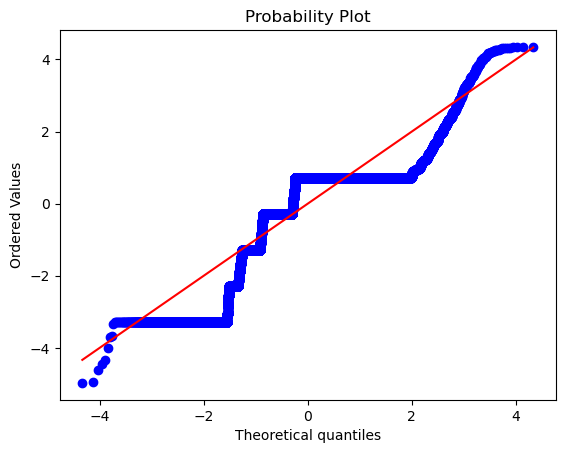

In [53]:
# QQ-plot

import matplotlib.pyplot as plt
import scipy.stats as stats

stats.probplot(model.resid, dist='norm', plot=plt)
plt.show()

In [54]:
# COOK'S DISTANCE

influence = model.get_influence()
c, p = influence.cooks_distance

df_clean_f['cooks_d'] = c

top_outliers = df_clean_f.sort_values('cooks_d', ascending=False).copy().head(200)
print(top_outliers[['delay_days', 'review_score', 'cooks_d']])

       delay_days  review_score   cooks_d
40010   57.803854           1.0  0.095631
38449   57.698160           1.0  0.093365
35260   56.732396           1.0  0.074738
78131   56.216771           1.0  0.066194
24433   55.873935           1.0  0.060997
...           ...           ...       ...
84437   29.689525           3.0  0.000976
61922   29.650058           3.0  0.000974
80256   13.971157           5.0  0.000968
93463   13.904618           5.0  0.000958
40750   13.805729           5.0  0.000944

[200 rows x 3 columns]


C:\Users\user\AppData\Local\Temp\ipykernel_28120\2263623070.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean_f['cooks_d'] = c


In [55]:
# COOK DISTANCE < 0.0001 FILTERED

df_delay_cook = df_clean_f[df_clean_f['cooks_d'] < 0.0001].copy()

X = sm.add_constant(df_delay_cook[['delay_days', 'delay_sq']])
model = sm.OLS(df_delay_cook['review_score'], X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           review_score   R-squared:                       0.192
Model:                            OLS   Adj. R-squared:                  0.192
Method:                 Least Squares   F-statistic:                 1.129e+04
Date:                Wed, 29 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:01:19   Log-Likelihood:            -1.4820e+05
No. Observations:               95000   AIC:                         2.964e+05
Df Residuals:                   94997   BIC:                         2.964e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.2881      0.004   1119.044      0.0

<Axes: xlabel='delay_days', ylabel='review_score'>

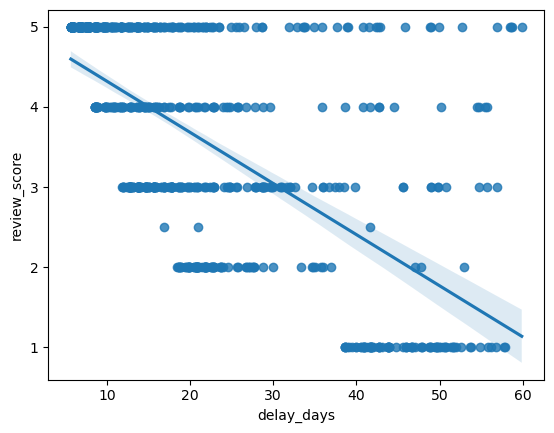

In [56]:
df_delay_exc = df_clean_f[df_clean_f['cooks_d'] >= 0.0001].copy()

sns.regplot(x='delay_days', y='review_score', data=df_delay_exc)

In [57]:
# OLS WITH D < 0.0001 REMOVED

X = sm.add_constant(df_delay_exc[['delay_days', 'delay_sq']])
model = sm.OLS(df_delay_exc['review_score'], X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           review_score   R-squared:                       0.467
Model:                            OLS   Adj. R-squared:                  0.465
Method:                 Least Squares   F-statistic:                     326.9
Date:                Wed, 29 Apr 2026   Prob (F-statistic):          1.05e-102
Time:                        12:01:20   Log-Likelihood:                -1070.5
No. Observations:                 750   AIC:                             2147.
Df Residuals:                     747   BIC:                             2161.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.9889      0.128     46.961      0.0

In [58]:
# OUT OF SAMPLE TEST (SHOULD WE REMOVE D > 0.0001 SPOTS OR NOT)

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

train, test = train_test_split(df_clean_f, test_size=0.2, random_state=42)

X_dirty = sm.add_constant(train[['delay_days', 'delay_sq']])
model_dirty = sm.OLS(train['review_score'], X_dirty).fit()

cooks_d = model_dirty.get_influence().cooks_distance[0]
train_clean = train[cooks_d < 0.0001]
X_clean = sm.add_constant(train_clean[['delay_days', 'delay_sq']])
model_clean = sm.OLS(train_clean['review_score'], X_clean).fit()

pred_dirty = model_dirty.predict(sm.add_constant(test[['delay_days', 'delay_sq']]))
pred_clean = model_clean.predict(sm.add_constant(test[['delay_days', 'delay_sq']]))

print(f"Error of dirty: {mean_squared_error(test['review_score'], pred_dirty)}")
print(f"Error of clean: {mean_squared_error(test['review_score'], pred_clean)}")

Error of dirty: 1.374553607112432
Error of clean: 1.4125906485443247


In [59]:
# WEIGHTED REVIEW SCORE

df_clean_f['delay_price'] = df_clean_f['delay_days'] * df_clean_f['items_total_price'].copy()

y = df_clean_f['review_score']
x = sm.add_constant(df_clean_f[['delay_days', 'delay_sq', 'items_total_price', 'delay_price']])

model = sm.OLS(y, x).fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           review_score   R-squared:                       0.163
Model:                            OLS   Adj. R-squared:                  0.163
Method:                 Least Squares   F-statistic:                     3509.
Date:                Wed, 29 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:01:20   Log-Likelihood:            -1.5117e+05
No. Observations:               95750   AIC:                         3.024e+05
Df Residuals:                   95745   BIC:                         3.024e+05
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 4.3015      0.00

C:\Users\user\AppData\Local\Temp\ipykernel_28120\2978938985.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean_f['delay_price'] = df_clean_f['delay_days'] * df_clean_f['items_total_price'].copy()


In [60]:
# ORDER COST & REVIEW SCORE

x = sm.add_constant(df_clean_f['items_total_price'])

model = sm.OLS(y, x).fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           review_score   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     89.67
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           2.87e-21
Time:                        12:01:20   Log-Likelihood:            -1.5965e+05
No. Observations:               95750   AIC:                         3.193e+05
Df Residuals:                   95748   BIC:                         3.193e+05
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 4.1863      0.00

In [61]:
# FREIGHT VALUE & REVIEW SCORE

x = sm.add_constant(df_clean['freight_total'])
y = df_clean['review_score']

model = sm.OLS(y, x).fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           review_score   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     115.1
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           7.89e-27
Time:                        12:01:20   Log-Likelihood:            -1.5952e+05
No. Observations:               95830   AIC:                         3.191e+05
Df Residuals:                   95828   BIC:                         3.191e+05
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             4.2781      0.012    362.542

In [62]:
# FREIGHT RATIO & REVIEW SCORE

df_clean['freight_ratio'] = df_clean['freight_total'] / df_clean['items_total_price']

x = sm.add_constant(df_clean['freight_ratio'])
model = sm.OLS(y, x).fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           review_score   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     38.49
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           5.53e-10
Time:                        12:01:21   Log-Likelihood:            -1.5989e+05
No. Observations:               95830   AIC:                         3.198e+05
Df Residuals:                   95828   BIC:                         3.198e+05
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             4.1859      0.006    665.971

In [63]:
# PAYMENT TYPE AND AVE CHECK

payments = load_data('order_payments_dataset.csv', '1efUSfLjg93ExNzAjTHNFTpVbp5umaa7x', encoding='utf-8', sep=',',
na_values = ['null', 'unknown', 'unavailable', 'error', 'NaN', 'NULL', 'UNKNOWN', 'ERROR'])
payments = payments.groupby('order_id').agg({
    'payment_value': 'sum',
    'payment_installments': 'max',
    'payment_type': lambda x: ', '.join(x.unique())
}).reset_index()

df_payments = df.merge(payments, on='order_id', how='inner', validate='one_to_one')
df_payments = df_payments[['payment_type', 'items_total_price', 'payment_value']].dropna()

In [64]:
# TEST D'AGOSTINO

from scipy.stats import normaltest

stat, pval = normaltest(df_payments['payment_value'])
stat, pval

(np.float64(151339.1699582847), np.float64(0.0))

<Axes: xlabel='payment_type', ylabel='payment_value'>

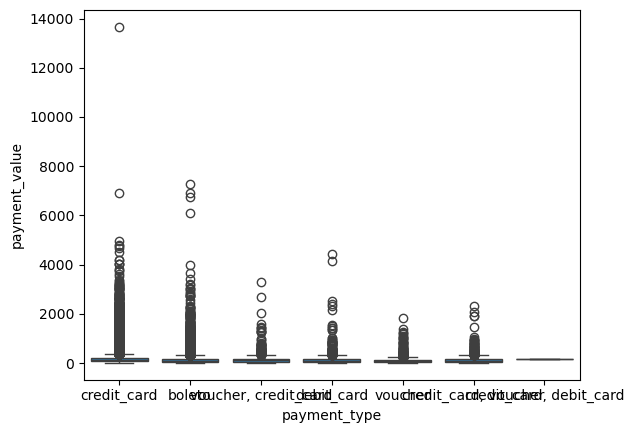

In [65]:
sns.boxplot(x='payment_type', y='payment_value', data=df_payments)

<Axes: xlabel='payment_type', ylabel='payment_value'>

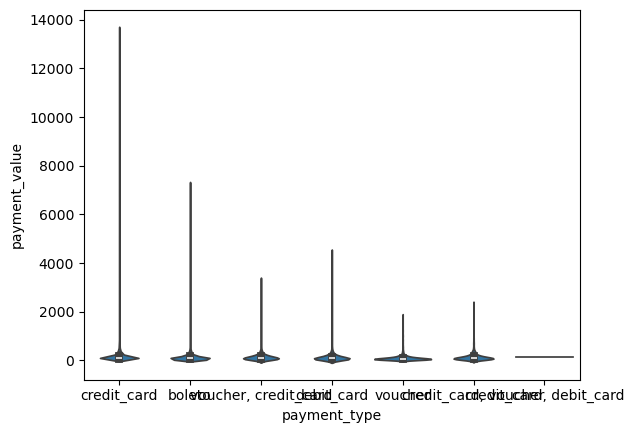

In [66]:
sns.violinplot(x='payment_type', y='payment_value', data=df_payments)

In [67]:
from scipy.stats import kruskal

groups = [group['payment_value'].values for name, group in df_payments.groupby('payment_type')]
stat, p = kruskal(*groups)

stat, p

(np.float64(924.7639015542686), np.float64(1.6631081807656604e-196))

In [68]:
pip install scikit-posthocs

Note: you may need to restart the kernel to use updated packages.


In [69]:
import scikit_posthocs as sp

dunn = sp.posthoc_dunn(
    df_payments,
    val_col = 'payment_value',
    group_col = 'payment_type',
    p_adjust = 'bonferroni'
)

dunn

,boleto,credit_card,"credit_card, debit_card","credit_card, voucher",debit_card,voucher,"voucher, credit_card"
boleto,1.000000e+00,2.660383e-110,1.0,8.720958e-01,3.414946e-01,6.294495e-37,3.082645e-03
credit_card,2.660383e-110,1.000000e+00,1.0,1.973449e-03,8.656181e-20,2.902808e-90,7.769247e-01
"credit_card, debit_card",1.000000e+00,1.000000e+00,1.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
"credit_card, voucher",8.720958e-01,1.973449e-03,1.0,1.000000e+00,2.744298e-02,1.409964e-23,1.000000e+00
debit_card,3.414946e-01,8.656181e-20,1.0,2.744298e-02,1.000000e+00,2.962850e-13,9.428503e-05
voucher,6.294495e-37,2.902808e-90,1.0,1.409964e-23,2.962850e-13,1.000000e+00,4.147931e-30
"voucher, credit_card",3.082645e-03,7.769247e-01,1.0,1.000000e+00,9.428503e-05,4.147931e-30,1.000000e+00


In [70]:
print(df_payments.groupby('payment_type').size())
print()
print(df_payments.groupby('payment_type')['payment_value'].var())
print()
print(df_payments.groupby('payment_type')['payment_value'].nunique())

payment_type
boleto                     19614
credit_card                73764
credit_card, debit_card        1
credit_card, voucher        1118
debit_card                  1520
voucher                     1540
voucher, credit_card        1108
dtype: int64

payment_type
boleto                     45599.247651
credit_card                50006.695512
credit_card, debit_card             NaN
credit_card, voucher       32370.792861
debit_card                 57536.089747
voucher                    17594.247165
voucher, credit_card       44892.704299
Name: payment_value, dtype: float64

payment_type
boleto                     10472
credit_card                24323
credit_card, debit_card        1
credit_card, voucher        1053
debit_card                  1378
voucher                     1342
voucher, credit_card        1040
Name: payment_value, dtype: int64


In [71]:
# LEVENE TEST

df_payments = df_payments[['payment_type', 'items_total_price']].dropna()
levene = pg.homoscedasticity(data=df_payments, dv='items_total_price', group='payment_type')
levene

,W,pval,equal_var
levene,22.258532,2.395523e-26,False


In [72]:
pg.welch_anova(dv='items_total_price', between='payment_type', data=df_payments)

,Source,ddof1,ddof2,F,p-unc,np2
0,payment_type,6,5300.373484,74.739264,7.216088e-90,0.002813


In [73]:
posthoc = pg.pairwise_gameshowell(data=df_payments, dv='items_total_price', between='payment_type')
posthoc

C:\Users\user\anaconda3\Lib\site-packages\pingouin\effsize.py:802: RuntimeWarning: Degrees of freedom <= 0 for slice
  poolsd = np.sqrt(((nx - 1) * x.var(ddof=1) + (ny - 1) * y.var(ddof=1)) / dof)
C:\Users\user\anaconda3\Lib\site-packages\numpy\_core\_methods.py:214: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,boleto,credit_card,121.929523,143.692234,-21.762711,1.642745,-13.247768,32330.537367,1.775557e-11,-0.102863
1,boleto,"credit_card, debit_card",121.929523,99.990000,21.939523,NaN,NaN,NaN,NaN,[0.10869091744529155]
2,boleto,"credit_card, voucher",121.929523,124.134383,-2.204860,5.380923,-0.409755,1295.896458,9.996357e-01,-0.011001
3,boleto,debit_card,121.929523,120.809770,1.119753,6.135412,0.182507,1701.173781,9.999969e-01,0.005483
4,boleto,voucher,121.929523,86.071403,35.858120,3.494803,10.260413,2227.093788,0.000000e+00,0.181765
5,boleto,"voucher, credit_card",121.929523,131.413448,-9.483925,6.306171,-1.503912,1232.176078,7.425898e-01,-0.046951
6,credit_card,"credit_card, debit_card",143.692234,99.990000,43.702234,NaN,NaN,NaN,NaN,[0.2041410975127255]
7,credit_card,"credit_card, voucher",143.692234,124.134383,19.557851,5.243884,3.729650,1169.229534,3.780093e-03,0.091593
8,credit_card,debit_card,143.692234,120.809770,22.882464,6.015586,3.803863,1572.524385,2.815435e-03,0.106694
9,credit_card,voucher,143.692234,86.071403,57.620831,3.279883,17.567951,1733.310403,8.062440e-13,0.270987


In [74]:
# FREIGHT VALUE & ITEMS PRICE

df_freight = df[['freight_total', 'items_total_price']].dropna()

x = sm.add_constant(df_freight['freight_total'])
y = df_freight['items_total_price']
model = sm.OLS(y, x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      items_total_price   R-squared:                       0.170
Model:                            OLS   Adj. R-squared:                  0.170
Method:                 Least Squares   F-statistic:                 2.026e+04
Date:                Wed, 29 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:02:12   Log-Likelihood:            -6.5867e+05
No. Observations:               98666   AIC:                         1.317e+06
Df Residuals:                   98664   BIC:                         1.317e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            46.0932      0.888     51.935

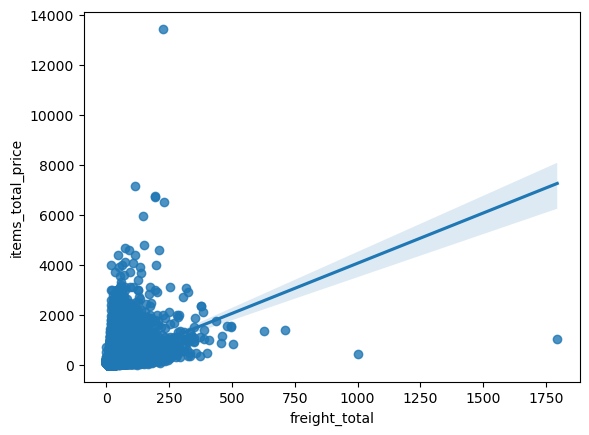

In [75]:
sns.regplot(y='items_total_price', x='freight_total', data=df_freight)
plt.show()

In [76]:
df_freight_filt = df_freight[(df_freight['freight_total'] < 550) & (df_freight['items_total_price'] < 5500)]

x = sm.add_constant(df_freight_filt['freight_total'])
y = df_freight_filt['items_total_price']
model = sm.OLS(y, x).fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      items_total_price   R-squared:                       0.186
Model:                            OLS   Adj. R-squared:                  0.186
Method:                 Least Squares   F-statistic:                     2533.
Date:                Wed, 29 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:02:47   Log-Likelihood:            -6.5305e+05
No. Observations:               98656   AIC:                         1.306e+06
Df Residuals:                   98654   BIC:                         1.306e+06
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            40.5912      1.694     23.958

In [77]:
# RAMSEY TEST

reset_results = dg.linear_reset(model, power=3, use_f=True)
reset_results

<class 'statsmodels.stats.contrast.ContrastResults'>
<F test: F=337.9334540238666, p=5.467869743235234e-147, df_denom=9.87e+04, df_num=2>

In [78]:
# FREIGHT_SQ ADDED

df_freight_filt['freight_sq'] = df_freight_filt['freight_total'] ** 2

x = sm.add_constant(df_freight_filt[['freight_total', 'freight_sq']])
y = df_freight_filt['items_total_price']
model = sm.OLS(y, x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      items_total_price   R-squared:                       0.191
Model:                            OLS   Adj. R-squared:                  0.191
Method:                 Least Squares   F-statistic:                 1.165e+04
Date:                Wed, 29 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:02:48   Log-Likelihood:            -6.5274e+05
No. Observations:               98656   AIC:                         1.305e+06
Df Residuals:                   98653   BIC:                         1.306e+06
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            23.1106      1.109     20.848

C:\Users\user\AppData\Local\Temp\ipykernel_28120\3117858975.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_freight_filt['freight_sq'] = df_freight_filt['freight_total'] ** 2


In [79]:
# RAMSEY TEST WITH FREIGHT_SQ

reset_results = dg.linear_reset(model, power=3, use_f=True)
reset_results

<class 'statsmodels.stats.contrast.ContrastResults'>
<F test: F=36.9116140963645, p=9.451151453237422e-17, df_denom=9.87e+04, df_num=2>

In [80]:
# BREUSCH-PAGAN TEST

labels = ['LM stat', 'LM p', 'F-stat', 'F p']
test_results = het_breuschpagan(model.resid, x)

print(dict(zip(labels, test_results)))

{'LM stat': np.float64(3062.1084401168587), 'LM p': np.float64(0.0), 'F-stat': np.float64(1580.0496193504794), 'F p': np.float64(0.0)}


In [81]:
# REGRESSION WITH LOG

df_freight_filt['log_price'] = np.log(df_freight_filt['items_total_price'])

x = sm.add_constant(df_freight_filt[['freight_total', 'freight_sq']])
y = df_freight_filt['log_price']
model = sm.OLS(y, x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.207
Model:                            OLS   Adj. R-squared:                  0.207
Method:                 Least Squares   F-statistic:                 1.291e+04
Date:                Wed, 29 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:02:48   Log-Likelihood:            -1.2163e+05
No. Observations:               98656   AIC:                         2.433e+05
Df Residuals:                   98653   BIC:                         2.433e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             3.8012      0.005    746.771

C:\Users\user\AppData\Local\Temp\ipykernel_28120\2623675204.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_freight_filt['log_price'] = np.log(df_freight_filt['items_total_price'])


In [82]:
# BREUSCH-PAGAN WITH LOG

labels = ['LM stat', 'LM p', 'F-stat', 'F p']
test_results = het_breuschpagan(model.resid, x)

print(dict(zip(labels, test_results)))

{'LM stat': np.float64(1931.5792243753492), 'LM p': np.float64(0.0), 'F-stat': np.float64(985.0464013857561), 'F p': np.float64(0.0)}


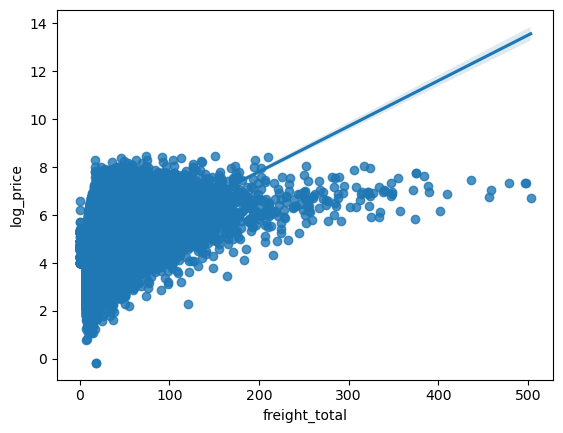

In [83]:
sns.regplot(y='log_price', x='freight_total', data=df_freight_filt)
plt.show()

In [84]:
# LOG THE X VARIABLE

df_freight_filt['log_freight'] = np.log1p(df_freight_filt['freight_total'])

x = sm.add_constant(df_freight_filt['log_freight'])
y = df_freight_filt['log_price']
model = sm.OLS(y, x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.214
Model:                            OLS   Adj. R-squared:                  0.214
Method:                 Least Squares   F-statistic:                 2.694e+04
Date:                Wed, 29 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:03:25   Log-Likelihood:            -1.2119e+05
No. Observations:               98656   AIC:                         2.424e+05
Df Residuals:                   98654   BIC:                         2.424e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           2.1223      0.014    147.551      

C:\Users\user\AppData\Local\Temp\ipykernel_28120\2989933799.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_freight_filt['log_freight'] = np.log1p(df_freight_filt['freight_total'])


In [85]:
# BREUSCH-PAGAN WITH X LOG

labels = ['LM stat', 'LM p', 'F-stat', 'F p']
test_results = het_breuschpagan(model.resid, x)

print(dict(zip(labels, test_results)))

{'LM stat': np.float64(522.9754010307325), 'LM p': np.float64(9.532515366548666e-116), 'F-stat': np.float64(525.7518090788366), 'F p': np.float64(4.780328129543792e-116)}


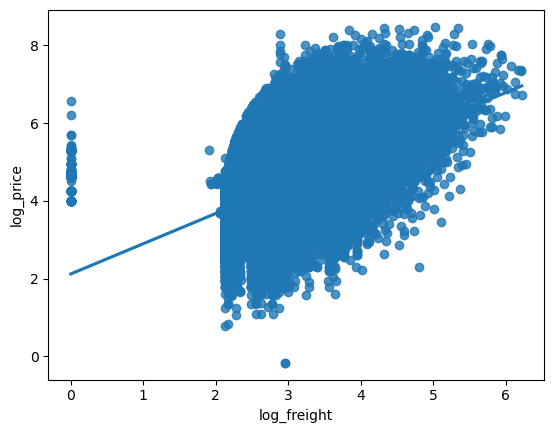

In [86]:
sns.regplot(y='log_price', x='log_freight', data=df_freight_filt)
plt.show()

In [87]:
# LOG SQUARED

df_freight_filt['log_sq_freight'] = df_freight_filt['log_freight'] ** 2

x = sm.add_constant(df_freight_filt[['log_freight', 'log_sq_freight']])
y = df_freight_filt['log_price']
model = sm.OLS(y, x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.228
Model:                            OLS   Adj. R-squared:                  0.228
Method:                 Least Squares   F-statistic:                 1.453e+04
Date:                Wed, 29 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:04:11   Log-Likelihood:            -1.2036e+05
No. Observations:               98656   AIC:                         2.407e+05
Df Residuals:                   98653   BIC:                         2.408e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              3.4658      0.036     96.

C:\Users\user\AppData\Local\Temp\ipykernel_28120\3450204437.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_freight_filt['log_sq_freight'] = df_freight_filt['log_freight'] ** 2


In [88]:
# BREUSCH-PAGAN WITH LOG SQUARED

labels = ['LM stat', 'LM p', 'F-stat', 'F p']
test_results = het_breuschpagan(model.resid, x)

print(dict(zip(labels, test_results)))

{'LM stat': np.float64(150.036651900006), 'LM p': np.float64(2.6299954569704186e-33), 'F-stat': np.float64(75.13030336846751), 'F p': np.float64(2.489701931407593e-33)}


In [89]:
# CUTTING FREIGHT = 0

df_freight_paid = df_freight_filt[df_freight_filt['freight_total'] > 0].copy()

df_freight_paid['log_freight'] = np.log(df_freight_paid['freight_total'])
df_freight_paid['log_sq_freight'] = df_freight_paid['log_freight'] ** 2

x = sm.add_constant(df_freight_paid[['log_freight', 'log_sq_freight']])
y = df_freight_paid['log_price']
model = sm.OLS(y, x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.243
Model:                            OLS   Adj. R-squared:                  0.243
Method:                 Least Squares   F-statistic:                 1.576e+04
Date:                Wed, 29 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:04:11   Log-Likelihood:            -1.1911e+05
No. Observations:               98318   AIC:                         2.382e+05
Df Residuals:                   98315   BIC:                         2.382e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              1.7236      0.053     32.

In [90]:
# BREUSCH-PAGAN WTH FREIGHT > 0

labels = ['LM stat', 'LM p', 'F-stat', 'F p']
test_results = het_breuschpagan(model.resid, x)

print(dict(zip(labels, test_results)))

{'LM stat': np.float64(205.79545059273428), 'LM p': np.float64(2.0515669937799074e-45), 'F-stat': np.float64(103.1104122975616), 'F p': np.float64(1.8476335002175565e-45)}


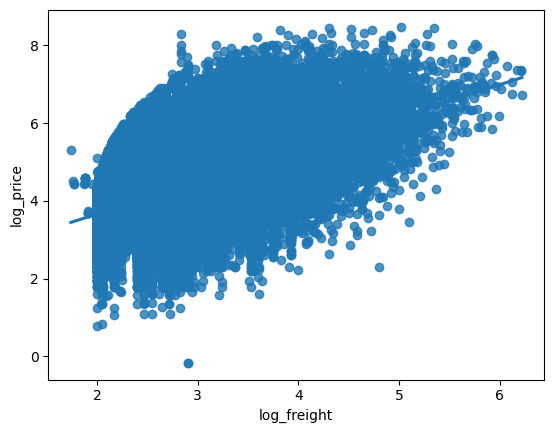

In [91]:
sns.regplot(y='log_price', x='log_freight', data=df_freight_paid)
plt.show()

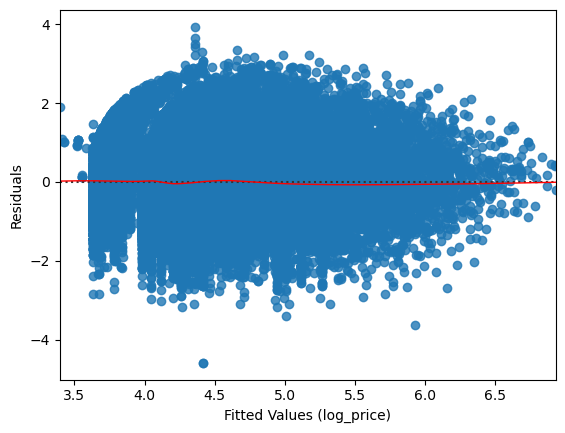

In [92]:
# RESIDPLOT

sns.residplot(x=model.fittedvalues, y=model.resid, lowess=True, 
              line_kws={'color': 'red', 'lw': 1})
plt.xlabel('Fitted Values (log_price)')
plt.ylabel('Residuals')
plt.show()

In [93]:
# OLS WITH ROBUST STANDARD ERRORS

rob_mod = sm.OLS(y, x).fit(cov_type='HC3')
print(rob_mod.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.243
Model:                            OLS   Adj. R-squared:                  0.243
Method:                 Least Squares   F-statistic:                 1.633e+04
Date:                Wed, 29 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:11:54   Log-Likelihood:            -1.1911e+05
No. Observations:               98318   AIC:                         2.382e+05
Df Residuals:                   98315   BIC:                         2.382e+05
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              1.7236      0.049     35.